# Archival Restore — Milestone A
## Preprocess 5 scanned pages → per-page artifacts (image + OCR + confidence)

This notebook is the **build-first** foundation for the MCP/A2A mini-series:
- **Post 1 (MCP):** a reliable *tool spine* that produces auditable per-page artifacts.
- **Post 2 (A2A):** orchestrate specialists over those artifacts.
- **Post 3 (Capstone):** evaluator-gated edits + scorecard.

**Milestone A goal:** Get consistent, repeatable page normalization + baseline OCR **per page (not whole PDF)** and write a `PageArtifact.json` bundle.

> Note: This notebook intentionally does **not** attempt “perfect cleanup.” It creates stable artifacts and instrumentation so your next agents can do their jobs.


In [1]:
from pathlib import Path
SOURCE_DIR = Path.cwd().parent.parent / 'src' / 'archival_restore'
import sys
sys.path.append(str(SOURCE_DIR))
from archival_restore.types import (
    PageArtifact, 
    EditProposal, 
    EvalDecision
)
from typing import List
from PIL import Image
from pdf2image import convert_from_path
from preprocess_utils import (
    preprocess_basic,
    preprocess_normalize,
    preprocess_denoise,
    preprocess_binarize_for_ocr,
)
from mcp_archival_server import (
    score_ocr,
    ocr_page
)


PREPROCESSORS = {
    "PreprocessBasic": preprocess_basic,
    "PreprocessNormalize": preprocess_normalize,
    "PreprocessDenoise": preprocess_denoise,
    "PreprocessBinarizeForOCR": preprocess_binarize_for_ocr,
}
LOAD_RAW = False

In [2]:
print("""
MCP demo steps:
1) In terminal (from repo root), run:
   python src/archival_restore/mcp_archival_server.py

2) Open MCP Inspector:
   npx -y @modelcontextprotocol/inspector

3) Connect to:
   http://localhost:8000/mcp

4) In Inspector:
   - verify tools list (DetectOrientation, PreprocessPage, OCRPage, WriteArtifact)
   - call DetectOrientation on one of your raw page PNGs
""")



MCP demo steps:
1) In terminal (from repo root), run:
   python src/archival_restore/mcp_archival_server.py

2) Open MCP Inspector:
   npx -y @modelcontextprotocol/inspector

3) Connect to:
   http://localhost:8000/mcp

4) In Inspector:
   - verify tools list (DetectOrientation, PreprocessPage, OCRPage, WriteArtifact)
   - call DetectOrientation on one of your raw page PNGs



## 1) Configure input / output

In [3]:
DATA_DIR = Path.cwd().parent.parent / 'assets' / 'datasets' / 'archival_restore'
OUT_DIR = Path.cwd().parent.parent / 'results' / 'archival_restore'
SOURCE_DIR = Path.cwd().parent.parent / 'src' / 'archival_restore'
sys.path.append(str(SOURCE_DIR))

DATA_FILES = sorted([p for p in DATA_DIR.iterdir() if p.suffix.lower() in {".pdf"}])

USE_MCP = False  # flip to True later

DPI = 300  # higher DPI improves OCR but costs time/memory
LANG = 'eng'

# a wrapper for the tool calls when MCP is wired
def tool_call(tool_name: str, **kwargs):
    return mcp_tools[tool_name](**kwargs)  # client call (later)



## 2) Extract pages as images
We do *per-page* processing to avoid timeouts and make A2A orchestration easy.


In [4]:

pages: List[Image.Image] = [y for x in DATA_FILES for y in convert_from_path(str(x), dpi=DPI) ]
print('Extracted pages:', len(pages))

# Save raw page images
raw_dir = OUT_DIR / 'raw_pages'
raw_dir.mkdir(exist_ok=True)
raw_paths = []
for i, pil_img in enumerate(pages, start=1):
    p = raw_dir / f'page_{i:02d}_raw.png'
    if LOAD_RAW:
        pil_img.save(p)
    raw_paths.append(p)

raw_paths[:2]

Extracted pages: 20


[PosixPath('/Users/douglasdaly/Documents/GitHub/Generative-AI/results/archival_restore/raw_pages/page_01_raw.png'),
 PosixPath('/Users/douglasdaly/Documents/GitHub/Generative-AI/results/archival_restore/raw_pages/page_02_raw.png')]

## 5) Generate per-page artifacts
Each page becomes a bundle:
- `page_##_raw.png`
- `page_##_clean.png`
- `page_##_ocr.txt`
- `page_##_artifact.json`
- trace metadata


In [5]:
from pathlib import Path
import json
from typing import List


clean_dir = OUT_DIR / "clean_pages"
artifact_dir = OUT_DIR / "artifacts"


# Decide when to stop iterating on preprocessing
def needs_more_preprocess(score: dict) -> bool:
    # tune these once you’ve seen a few pages
    if score.get("alpha_ratio", 0.0) < 0.70:
        return True
    if score.get("mean_conf", 0.0) < 0.85:
        return True
    if score.get("low_conf_rate", 1.0) > 0.40:
        return True
    return False

def rank_score(score: dict):
    # prioritize "looks like text" then confidence, then low-conf rate
    return (
        score.get("alpha_ratio", 0.0),
        score.get("mean_conf", 0.0),
        -score.get("low_conf_rate", 1.0),
    )

artifacts: List[PageArtifact] = []

for page_i, raw_path in enumerate(raw_paths, start=1):
    raw_path = Path(raw_path)
    trace = []
    trace.append({"step": "load", "path": str(raw_path)})

    # Orientation (for reporting + debugging; preprocessors also handle internally)
    rot, rot_conf, osd_raw = detect_orientation(raw_path)
    trace.append({"step": "DetectOrientation", "rotate": rot, "conf": rot_conf, "note": (osd_raw or "")[:200]})

    # 1) Always run Basic first
    basic_name = "PreprocessBasic"
    basic_clean = clean_dir / f"page_{page_i:02d}_raw__{basic_name}.png"
    PREPROCESSORS[basic_name](raw_path, basic_clean)
    trace.append({"step": basic_name, "out": str(basic_clean)})

    basic_score = score_ocr(basic_clean, lang=LANG)
    trace.append({"step": "ScoreOCR", "preprocess": basic_name, **{k: basic_score.get(k) for k in ["mean_conf", "low_conf_rate", "alpha_ratio", "chars"]}})

    candidates = [{
        "name": basic_name,
        "clean_image": str(basic_clean),
        "score": basic_score,
    }]

    # 2) Only run more variants if Basic looks bad (stopping criterion)
    if needs_more_preprocess(basic_score):
        for name, fn in PREPROCESSORS.items():
            if name == basic_name:
                continue
            clean_path = clean_dir / f"page_{page_i:02d}_raw__{name}.png"
            fn(raw_path, clean_path)
            sc = score_ocr(clean_path, lang=LANG)
            trace.append({"step": "ScoreOCR", "preprocess": name, **{k: sc.get(k) for k in ["mean_conf", "low_conf_rate", "alpha_ratio", "chars"]}})
            candidates.append({"name": name, "clean_image": str(clean_path), "score": sc})

    # 3) Choose best
    candidates_sorted = sorted(candidates, key=lambda c: rank_score(c["score"]), reverse=True)
    chosen = candidates_sorted[0]
    chosen_name = chosen["name"]
    clean_path = Path(chosen["clean_image"])
    trace.append({"step": "choose_preprocess", "chosen": chosen_name})

    # 4) OCR only once (on chosen)
    ocr = ocr_page(clean_path, lang=LANG)
    trace.append({"step": "OCRPage", "mean_conf": ocr.get("mean_conf", 0.0)})

    ocr_text_path = artifact_dir / f"page_{page_i:02d}_ocr.txt"
    ocr_text_path.write_text(ocr.get("text", ""), encoding="utf-8")

    artifact_json_path = artifact_dir / f"page_{page_i:02d}_artifact.json"
    payload = {
        "page_index": page_i,
        "source_image": str(raw_path),
        "clean_image": str(clean_path),
        "preprocess": {"name": chosen_name},
        "orientation": {"rotate_deg": rot, "conf": rot_conf},
        # Deskew is now "inside" preprocess tools; keep field if you want but set None
        "deskew": {"angle_deg": None},
        "scores": {
            "leaderboard": [
                {"name": c["name"], "clean_image": c["clean_image"], **{k: c["score"].get(k) for k in ["mean_conf", "low_conf_rate", "alpha_ratio", "printable_ratio", "chars"]}}
                for c in candidates_sorted
            ]
        },
        "ocr": {
            "mean_conf": ocr.get("mean_conf", 0.0),
            "tokens": (ocr.get("tokens", [])[:2000] if isinstance(ocr.get("tokens", []), list) else []),
        },
        "paths": {"ocr_text": str(ocr_text_path)},
        "trace": trace,
    }
    artifact_json_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")

    artifacts.append(PageArtifact(
        page_index=page_i,
        source_image=str(raw_path),
        clean_image=str(clean_path),
        orientation_rotate_deg=rot,
        orientation_conf=rot_conf,
        deskew_angle_deg=None,
        ocr_mean_conf=ocr.get("mean_conf", 0.0),
        ocr_text_path=str(ocr_text_path),
        artifact_json_path=str(artifact_json_path),
        trace=trace,
    ))

print("Artifacts written:", len(artifacts))


NameError: name 'detect_orientation' is not defined

## 6) Quick visual check (1 page)
Change `PAGE_TO_VIEW` to spot-check results.


Page 14
Rotate: 180 conf: 4.07
Deskew angle: None
OCR mean conf: 0.8701988636363636


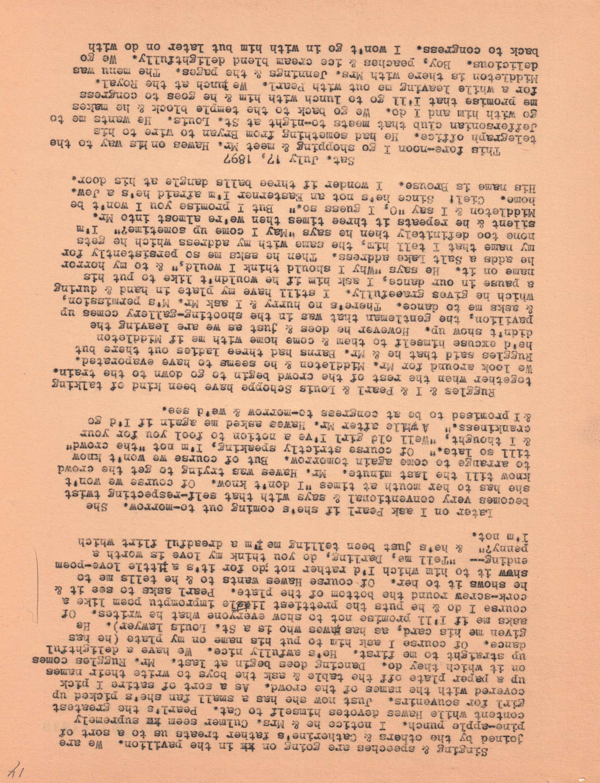

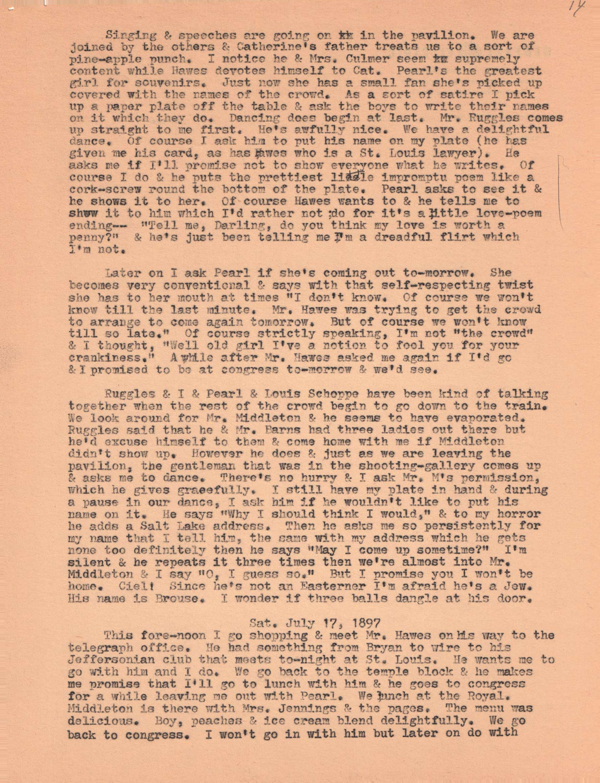


--- OCR snippet ---
*    L                    ;                                             / a

Singing &% speeches are going on kk in the pavilion. We are
joined by the others & Catherine's father treats us to a sert of
pine-epple punch. I notice he & Mrs. Culmer seem km supremely
content while Hawes devotes himself to Cat. Pearl's the greatest
girl for souvenirs. dust now she has a small fan shets picked up
covered with the names of the crowd. As a sort of satire I pick
up a paper plate off the table & ask the boys to write thoir names
on it which they do. Dancing dees begin at last. Mrs Ruggles comes
up strai


In [ ]:
from IPython.display import display

PAGE_TO_VIEW = 14
a = artifacts[PAGE_TO_VIEW - 1]
print('Page', a.page_index)
print('Rotate:', a.orientation_rotate_deg, 'conf:', a.orientation_conf)
print('Deskew angle:', a.deskew_angle_deg)
print('OCR mean conf:', a.ocr_mean_conf)

display(Image.open(a.source_image).resize((600, int(600 * Image.open(a.source_image).height / Image.open(a.source_image).width))))
display(Image.open(a.clean_image).resize((600, int(600 * Image.open(a.clean_image).height / Image.open(a.clean_image).width))))

print('\n--- OCR snippet ---')
print(Path(a.ocr_text_path).read_text(encoding='utf-8')[:600])

In [ ]:
import pandas as pd
from pathlib import Path

rows = []
for a in artifacts:
    rows.append({
        "page": a.page_index,
        "rotate_deg": a.orientation_rotate_deg,
        "rot_conf": round(a.orientation_conf, 2),
        "deskew_deg": (round(a.deskew_angle_deg, 2) if a.deskew_angle_deg is not None else None),
        "ocr_mean_conf": round(a.ocr_mean_conf, 3),
        "raw": Path(a.source_image).name,
        "clean": Path(a.clean_image).name,
    })

df = pd.DataFrame(rows)

df["ocr_chars"] = df["page"].apply(lambda p: len(Path(artifacts[p-1].ocr_text_path).read_text(encoding="utf-8")))
df["needs_attention"] = (
    (df["ocr_mean_conf"] < 0.88) #|
    #(df["deskew_deg"].abs() > 0.90)
)

df["needs_human_review"] = (
    (df["ocr_mean_conf"] < 0.82) #|
#    (df["deskew_deg"].abs() > 1.05)
)

summary = {
    "pages": len(df),
    "needs_attention": int(df["needs_attention"].sum()),
    "needs_human_review": int(df["needs_human_review"].sum()),
}
print(summary)

df[df["needs_attention"]].sort_values("ocr_mean_conf")[["page","ocr_mean_conf","deskew_deg","ocr_chars","raw","clean"]]
#display(df[["page","ocr_mean_conf","ocr_chars","raw","clean","needs_attention","needs_human_review"]])


{'pages': 20, 'needs_attention': 2, 'needs_human_review': 0}


,page,ocr_mean_conf,deskew_deg,ocr_chars,raw,clean
13,14,0.870,None,3568,page_14_raw.png,page_14_raw__PreprocessBasic.png
4,5,0.875,None,3421,page_05_raw.png,page_05_raw__PreprocessBasic.png


## Post-processing
### Identify candidates to clean up text files & perform cleanup

In [20]:
from __future__ import annotations
from pathlib import Path
import sys
import hashlib, json, re
from json import JSONDecodeError
import datetime
from docx import Document
from docx.shared import Pt, Inches
from typing import Any, Tuple
from langchain_ollama import ChatOllama 
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.pagesizes import letter
from reportlab.lib.units import inch
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, PageBreak
from html import escape as html_escape
from dataclasses import dataclass, field
from langchain_core.prompts import ChatPromptTemplate

SOURCE_DIR = Path.cwd().parent.parent / 'src' / 'archival_restore'
sys.path.append(str(SOURCE_DIR))
from cleanup_utils import build_cleanup_candidates, apply_cleanup_rules, stitch_pages

RESULTS_DIR = Path.cwd().parent.parent / 'results' / 'archival_restore'
PROCESSED_DIR = RESULTS_DIR / "processed_pages"

# Define directories for each processing step
OCR_RAW = PROCESSED_DIR / "ocr"
OCR_CLEANED = PROCESSED_DIR / "ocr_clean"
OCR_MANUAL_CORRECTED = PROCESSED_DIR / "ocr_manual_corrected"
OCR_CORRECTED = PROCESSED_DIR / "ocr_llm_corrected"
OCR_PREPUBLISH = PROCESSED_DIR / "prepublished"
OCR_FORMATTED = PROCESSED_DIR / "formatted"
OCR_RENDERED = PROCESSED_DIR / "rendered"

In [21]:
DEBUG = False

CODE_FENCE_RE = re.compile(r"^```(?:json)?\s*|\s*```$", re.IGNORECASE | re.MULTILINE)
DATE_PREFIX_RE = re.compile(
    r"""^\s*
    (?P<wd>[A-Za-z]{3,9})\.?,?\s+
    (?P<mo>[A-Za-z]{3,9})\.?,?\s+
    (?P<day>[0-9A-Za-z]{1,4})
    (?P<tail>.*)$
    """,
    re.IGNORECASE | re.VERBOSE
)
DATE_HEAD_RE = re.compile(r"^\s*([A-Za-z]{3,10})\.?\s+([A-Za-z]{3,10}\.?)\s+(.+?)\s*$")


JSON_OBJ_RE = re.compile(r"\{.*\}", re.DOTALL)
MID_DATE_RE = re.compile(r"(.*?[\.\!\?])\s+([A-Za-z]{3,10}[.,]?\s+[A-Za-z]{3,10}\.?\s+.+)$")
PAGE_NUM_RE = re.compile(r"(\d{1,5})")
PRESERVE_TOKENS = {"altho", "mamma"}

QUOTE_START_RE = re.compile(r'^\s*(["“\'\(\[])')
REDACTION_RE = re.compile(r"(?i)\bx{4,}\b")

# only used in the day slot, and only if the result becomes 1..31
DAY_OCR_MAP = {"ve": "7", "v": "7", "l": "1", "i": "1", "o": "0"}
MONTH_NUM = {
    "January": 1, "February": 2, "March": 3, "April": 4, "May": 5, "June": 6,
    "July": 7, "August": 8, "September": 9, "October": 10, "November": 11, "December": 12
}

WD_MAP = {
    "sun": "Sun", "sune": "Sun", "sund": "Sun", "sunday": "Sun",
    "mon": "Mon", "mone": "Mon", "monday": "Mon", "hone": "Mon",
    "tue": "Tue", "tues": "Tue", "tuesday": "Tue", "tuee": "Tue", # OCR: Tuee -> Tue
    "wed": "Wed", "wede": "Wed", "wednesday": "Wed",
    "thu": "Thu", "thue": "Thu", "thurs": "Thu", "thursday": "Thu",
    "fri": "Fri", "frie": "Fri", "friday": "Fri",
    "sat": "Sat", "sate": "Sat", "saturday": "Sat",
}

MO_MAP = {
    "jan": "January", "jan.": "January",
    "feb": "February", "feb.": "February",
    "mar": "March", "mar.": "March",
    "apr": "April", "apr.": "April",
    "may": "May",
    "jun": "June", "jun.": "June", "june": "June",
    "jul": "July", "jul.": "July", "july": "July",
    "aug": "August", "aug.": "August",
    "sep": "September", "sep.": "September", "sept": "September", "sept.": "September",
    "oct": "October", "oct.": "October",
    "nov": "November", "nov.": "November",
    "dec": "December", "dec.": "December",
}

# For more subtle changes, do a mapping from a phrase
manual_edits_by_page = {
  "page_01": [{"old":"fiery furnace of\nlifes;e","new":"fiery furnace of\nlife.","left":"through the ", "right":" ... It may","reason":"OCR punctuation", "confidence": 1.0}],
  "page_02": [{"old": "h, the years we waste and the tears", "new": "Oh, the years we waste and the tears", "left": "", 'right': ' we waste\n* And th', 'reason': 'manual', 'confidence': 1.0},
    {"old":"Work is over, play begune","new":"Work is over, play begun.","left":"\"","right":"\"","reason":"OCR spelling", "confidence": 1.0},
    {"old":"odiovs","new":"odious","left":"child, ","right":" creatures","reason":"OCR v->u", "confidence": 1.0},
    {"old":"Sate, June 5/97","new":"Sat., June 5/97","left":"\n","right":" \"One must","reason":"Normalize weekday abbrev punctuation", "confidence": 1.0},
    {"old":"Givine in uniform", "new":"divine in uniform", "left":"\n", "right" : ", but one", "reason":"OCR spelling", "confidence":1.0 }],
  "page_03": [{"old":"Alli®sdoes","new":"Allie does","left":"nor care to. ","right":" & I could get","reason":"OCR symbol + spacing", "confidence": 1.0},
    {"old":"Fred? 0, that's Fred,","new":"Fred? O, that's Fred,","left":"\"","right":"\"","reason":"OCR 0->O", "confidence": 1.0},
    {"old":"nw","new":"now","left":"so much but ","right":" I believe","reason":"OCR missing o", "confidence": 1.0},
    {'old': 'Where*tye', 'new': "Where've", 'left': "that's Fred,\n", 'right': ' you been all your', 'reason': 'manual', 'confidence': 1.0},
    {'old': 'married KXXXEXM', 'new': 'married XXXXXX', 'left': ' ago & his mother\n', 'right': ' have an idea that', 'reason': 'manual', 'confidence': 1.0},
    {"old": "he'g a little biteesomething", "new":"he's a little bit-something", "left": "idea that ", "right":"\nof a flirt", "reason": "OCR word break", "confidence": 1.0},
    {"old": "baklc there.", 'new': 'back there.', 'left': 'n he came running\n', 'right': ' he! he! ', 'reason': 'manual', 'confidence': 1.0} ],
  "page_17": [{"old": "bedy's", "new": "body's", "left":"every drop of blood in my ", "right":"\ntingling"},
            {"old": "Pap", "new": "Papa", "left":"crowded & ", "right":" gave me "}]}




In [22]:
from typing import List, Optional
from pydantic import BaseModel, Field, conint, confloat
from langchain_ollama import ChatOllama
def normalize_anchor(e: dict[str, Any], text: str) -> dict[str, Any]:
    old = str(e.get("old","") or "")
    left = str(e.get("left","") or "")
    right = str(e.get("right","") or "")
    if not old:
        return e

    def ok(l: str, r: str) -> bool:
        if old in l or old in r:
            return False
        needle = l + old + r
        return text.count(needle) == 1

    # already good
    if ok(left, right):
        return e

    # old accidentally embedded in left
    if old in left:
        pre, post = left.rsplit(old, 1)  # use last occurrence
        l2 = pre
        r2 = post + right
        if ok(l2, r2):
            e = dict(e)
            e["left"] = l2
            e["right"] = r2
            return e

    # old accidentally embedded in right
    if old in right:
        pre, post = right.split(old, 1)  # first occurrence
        l2 = left + pre
        r2 = post
        if ok(l2, r2):
            e = dict(e)
            e["left"] = l2
            e["right"] = r2
            return e

    return e

def find_unique_anchor(text: str, needle: str) -> list[int]:
    hits = [m.start() for m in re.finditer(re.escape(needle), text)]
    if len(hits) != 0:
        return hits

    # whitespace-flex fallback
    pat = re.escape(needle)
    pat = pat.replace(r"\ ", r"\s+").replace(r"\n", r"\s+").replace(r"\t", r"\s+")
    return [m.start() for m in re.finditer(pat, text)]


def spans_overlap(a: Tuple[int,int], b: Tuple[int,int]) -> bool:
    return not (a[1] <= b[0] or b[1] <= a[0])

class SpanEdit(BaseModel):
    start: conint(ge=0)
    end: conint(ge=0)
    old: str
    new: str
    reason: str = ""
    confidence: confloat(ge=0.0, le=1.0) = 0.9

def _get_field(e, key: str):
    if isinstance(e, dict):
        return e[key]
    return getattr(e, key)

@dataclass
class ApplyStats:
    n_edits_applied: int
    n_edits_rejected: int
    changed_chars: int
    rejects: list[dict[str, Any]]


def apply_anchored_edits(
    text: str,
    edits: list[dict[str, Any]],
    *,
    max_changed_frac: float = 0.02,
) -> tuple[str, ApplyStats]:
    rejects: list[dict[str, Any]] = []
    located: list[tuple[int,int,str,str,dict[str,Any]]] = []

    if not edits:
        return text, ApplyStats(0, 0, 0, [])

    for e in edits:
        if not isinstance(e, dict):
            rejects.append({"edit": e, "why": "edit_not_object"})
            continue

        # normalize FIRST (so we can salvage "old embedded in left/right")
        e = normalize_anchor(e, text)

        old = str(e.get("old", "") or "")
        new = str(e.get("new", "") or "")
        left = str(e.get("left", "") or "")
        right = str(e.get("right", "") or "")
        reason = str(e.get("reason", "") or "").lower()

        if not old or not new or old == new:
            rejects.append({"edit": e, "why": "bad_old_new"})
            continue
        if old.lower() in PRESERVE_TOKENS:
            rejects.append({"edit": e, "why": "preserve_token"})
            continue

        min_side = 8
        min_one_side = 14

        # only now enforce "old not in hooks"
        if old in left or old in right:
            rejects.append({"edit": e, "why": "bad_context_contains_old"})
            continue

        both_short = (len(left) < min_side and len(right) < min_side)

        if left == "" and len(right) < min_one_side:
            rejects.append({"edit": e, "why": "bad_context_start_needs_more_right"})
            continue
        if right == "" and len(left) < min_one_side:
            rejects.append({"edit": e, "why": "bad_context_end_needs_more_left"})
            continue
        if any(k in reason for k in ("modern", "paraphrase", "translate", "synonym")):
            rejects.append({"edit": e, "why": "banned_reason"})
            continue

        e = normalize_anchor(e, text)

        old = str(e.get("old","") or "")
        new = str(e.get("new","") or "")
        left = str(e.get("left","") or "")
        right = str(e.get("right","") or "")

        # NOW enforce "old not in hooks"
        if old in left or old in right:
            rejects.append({"edit": e, "why": "bad_context_contains_old"})
            continue

        hits = find_unique_anchor(text, left + old + right)

        if len(hits) == 0:
            rejects.append({"edit": e, "why": "anchor_not_found"})
            continue
        if len(hits) > 1:
            rejects.append({"edit": e, "why": "anchor_not_unique", "hits": len(hits), "both_short": both_short})
            continue

        # start-of-text with whitespace tolerance
        if left == "":
            if text[:hits[0]].strip() != "":  # <-- FIX 2
                rejects.append({"edit": e, "why": "not_start_of_text"})
                continue

        start = hits[0] + len(left)
        end = start + len(old)

        if text[start:end] != old:
            rejects.append({"edit": e, "why": "old_mismatch"})
            continue

        for m in REDACTION_RE.finditer(text):
            if spans_overlap((start, end), (m.start(), m.end())):
                rejects.append({"edit": e, "why": "touches_redaction"})
                break
        else:
            located.append((start, end, old, new, e))

    located.sort(key=lambda t: (t[0], t[1]))
    non_overlapping: list[tuple[int,int,str,str,dict[str,Any]]] = []
    applied = []
    for start, end, old, new, e in non_overlapping:
        applied.append({
            "start": start,
            "end": end,
            "old": old,
            "new": new,
            "left": e.get("left",""),
            "right": e.get("right",""),
            "reason": e.get("reason",""),
            "confidence": e.get("confidence", None),
        })

    for item in located:
        if non_overlapping and spans_overlap((item[0], item[1]), (non_overlapping[-1][0], non_overlapping[-1][1])):
            rejects.append({"edit": item[4], "why": "overlap"})
        else:
            non_overlapping.append(item)

    changed = sum(abs((end-start) - len(new)) for start,end,old,new,_ in non_overlapping)
    if len(text) > 0 and (changed / len(text)) > max_changed_frac:
        rejects.append({"why": "too_many_changes", "changed": changed, "len": len(text)})
        return text, ApplyStats(0, len(edits), 0, rejects)

    out = text
    for start, end, old, new, _ in sorted(non_overlapping, key=lambda t: t[0], reverse=True):
        out = out[:start] + new + out[end:]

    return out, ApplyStats(
        n_edits_applied=len(non_overlapping),
        n_edits_rejected=len(edits) - len(non_overlapping),
        changed_chars=changed,
        rejects=rejects,
    )



#### Deterministic cleanup to raw OCR text
Before doing initial LLM correction, correct OCR errors which can be identified and fixed deterministically.

In [23]:
# Apply mapping rules generated through debugging.
result = apply_cleanup_rules(OCR_RAW, OCR_CLEANED)


In [24]:

# Apply manually determined cleanup rules by page
files = sorted(OCR_CLEANED.glob("*_cleaned.txt"))
for fp in files:
    page_id = '_'.join(str(fp).split("/")[-1].split("_")[:2])
    manual = manual_edits_by_page.get(page_id)
    text_raw = fp.read_text(errors="replace")
    text_clean, stats_manual = apply_anchored_edits(text_raw, manual, max_changed_frac=0.05)
    out_fp = OCR_MANUAL_CORRECTED / f"{page_id}_manual_corrected.txt"
    out_fp.write_text(text_clean, encoding="utf-8")


#### Correct OCR errors with LLM

In [25]:
REDACTION_RE = re.compile(r"X{4,}")

@dataclass
class ApplyStats:
    n_edits_applied: int
    n_edits_rejected: int
    changed_chars: int
    rejects: list[dict[str, Any]]

def apply_spanid_edits(
    text: str,
    spans: list[dict[str, Any]],
    edits: list[Any],
    *,
    max_changed_frac: float = 0.05,
) -> tuple[str, ApplyStats]:
    span_by_id = {s["span_id"]: s for s in spans}
    rejects: list[dict[str, Any]] = []
    located: list[tuple[int, int, str, str, dict[str, Any]]] = []  # start,end,old,new,meta

    for e in edits:
        # allow dict or pydantic objects
        sid = getattr(e, "span_id", None) or (e.get("span_id") if isinstance(e, dict) else None)
        new = getattr(e, "new", None) or (e.get("new") if isinstance(e, dict) else None)
        reason = getattr(e, "reason", "") or (e.get("reason","") if isinstance(e, dict) else "")
        conf = getattr(e, "confidence", 0.0) if not isinstance(e, dict) else float(e.get("confidence", 0.0))

        if not sid or new is None:
            rejects.append({"edit": str(e)[:200], "why": "missing_span_id_or_new"})
            continue
        if sid not in span_by_id:
            rejects.append({"edit": {"span_id": sid}, "why": "unknown_span_id"})
            continue

        s = span_by_id[sid]
        start, end, old = int(s["start"]), int(s["end"]), str(s["old"])

        # Must match current text exactly
        if text[start:end] != old:
            rejects.append({"edit": {"span_id": sid}, "why": "span_old_mismatch"})
            continue

        # Never touch redactions: easiest rule is “if span contains redaction, reject any edit”
        if REDACTION_RE.search(old):
            if old != new:
                rejects.append({"edit": {"span_id": sid}, "why": "span_contains_redaction"})
            continue

        # Skip no-ops
        if new == old:
            continue

        located.append((start, end, old, str(new), {"span_id": sid, "reason": reason, "confidence": conf}))

    # Reject overlaps
    located.sort(key=lambda t: (t[0], t[1]))
    non_overlapping = []
    for item in located:
        if non_overlapping and not (item[1] <= non_overlapping[-1][0] or item[0] >= non_overlapping[-1][1]):
            rejects.append({"edit": item[4], "why": "overlap"})
        else:
            non_overlapping.append(item)

    changed = sum(abs((end-start) - len(new)) for start, end, old, new, _ in non_overlapping)
    if len(text) and (changed / len(text)) > max_changed_frac:
        rejects.append({"why": "too_many_changes", "changed": changed, "len": len(text)})
        return text, ApplyStats(0, len(edits), 0, rejects)

    out = text
    applied_meta = []
    for start, end, old, new, meta in sorted(non_overlapping, key=lambda t: t[0], reverse=True):
        out = out[:start] + new + out[end:]
        applied_meta.append(meta)

    return out, ApplyStats(
        n_edits_applied=len(non_overlapping),
        n_edits_rejected=len(edits) - len(non_overlapping),
        changed_chars=changed,
        rejects=rejects,
    )


In [26]:
import re
from dataclasses import dataclass
from typing import Any

PARA_SPLIT_RE = re.compile(r"\n\s*\n", re.M)

def make_spans_all_paras(text: str) -> list[dict[str, Any]]:
    """
    Split text into paragraphs (separated by blank lines).
    Spans include start/end offsets into *this exact text*.
    """
    spans: list[dict[str, Any]] = []
    sid = 0

    # Walk using regex so we can compute true offsets
    parts = []
    last = 0
    for m in PARA_SPLIT_RE.finditer(text):
        parts.append((last, m.start()))
        last = m.end()
    parts.append((last, len(text)))

    for (start, end) in parts:
        para = text[start:end]
        if not para.strip():
            continue
        sid += 1
        spans.append({
            "span_id": f"s{sid:04d}",
            "start": start,
            "end": end,
            "old": para,  # exact slice
        })
    return spans


In [27]:

class SpanEdit(BaseModel):
    span_id: str
    new: str
    reason: str = ""
    confidence: float = Field(ge=0.0, le=1.0)

class Patch(BaseModel):
    page_id: str
    source_sha1: str
    edits: List[SpanEdit] = []
    notes: List[str] = []


llm = ChatOllama(
    model="qwen2.5:32b-instruct-q6_K",
    temperature=0.0,
    options={
        "num_ctx": 8192,   # start here; raise later if you need it
        # "num_predict": 1024,  # optional cap on output tokens
    },
)

prompt = ChatPromptTemplate.from_messages([
("system",
"You are an OCR proofreader for a 1950s typewritten transcription of an 1897 diary.\n"
"Fix only OCR/typing artifacts. Do NOT modernize. Do NOT add info. Do NOT change XXXXXX redactions.\n"
"You may ONLY edit within the provided spans.\n"
"Return edits by span_id, replacing the ENTIRE span text with corrected text.\n"
"If a span is fine, omit it.\n"
"If a span ends a sentence, ensure it ends with correct punctuation.\n"
),
("user",
"page_id: {page_id}\n"
"source_sha1: {source_sha1}\n\n"
"SPANS (JSON). Each span.old is exact text. Output Patch JSON only.\n"
"{spans_json}\n")
])

chain = prompt | llm.with_structured_output(Patch, method="json_schema")

def spans_to_json(spans) -> str:
    def to_dict(x):
        if hasattr(x, "model_dump"):
            return x.model_dump()
        if hasattr(x, "__dict__"):
            return dict(x.__dict__)
        return x
    spans_payload = [to_dict(s) for s in spans]
    return json.dumps(spans_payload, ensure_ascii=False)

def get_patch(page_id, source_sha1, spans):
    spans_json = spans_to_json(spans)
    return chain.invoke({
        "page_id": page_id,
        "source_sha1": source_sha1,
        "spans_json": spans_json
    })


In [28]:
def unwrap_hardwraps(s: str) -> str:
    # preserve blank lines (paragraph breaks), collapse single newlines to spaces
    paras = re.split(r"\n\s*\n", s.strip())
    paras = [" ".join(p.splitlines()).strip() for p in paras]
    return "\n\n".join(paras) + "\n"

def sha1_text(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

files = sorted(OCR_MANUAL_CORRECTED.glob("*_manual_corrected.txt"))

for fp in files:
    page_id = fp.stem.replace("_manual_corrected", "")

    text0 = fp.read_text(encoding="utf-8", errors="replace")

    # Normalize layout FIRST
    text1 = unwrap_hardwraps(text0)

    # Build spans from the SAME text we will apply edits to
    spans = make_spans_all_paras(text1)

    h = sha1_text(text1)
    patch = get_patch(page_id, h, spans)   # patch.edits should be span_id/new edits

    text2, stats_llm = apply_spanid_edits(text1, spans, patch.edits, max_changed_frac=0.05)

    out_fp = OCR_CORRECTED / f"{page_id}_llm_corrected.txt"
    out_fp.write_text(text2, encoding="utf-8")



#### Stitch into a text diary

In [29]:
# Combine text files into one text diary
stitch_pages(
    clean_dir=OCR_CORRECTED,
    out_path=OCR_CORRECTED / "diary_published_v1.txt",
    pattern="*_llm_corrected.txt"
)


'/Users/douglasdaly/Documents/GitHub/Generative-AI/results/archival_restore/processed_pages/ocr_llm_corrected/diary_published_v1.txt'

In [30]:
def page_sort_key(p: Path) -> int:
    m = PAGE_NUM_RE.search(p.stem)
    return int(m.group(1)) if m else 10**9

def _clean_token(s: str) -> str:
    # keep only letters+digits, drop punctuation like "Jul." -> "jul"
    return re.sub(r"[^A-Za-z0-9]", "", s).lower()

def _key_token(s: str) -> str:
    # for WD/MO lookup keys: letters only
    return re.sub(r"[^A-Za-z]", "", s).lower()


def normalize_date_prefix(p: str, *, default_year: int = 1897) -> tuple[str, str] | None:
    s = p.strip()
    if not s:
        return None

    # guardrails: avoid styling prose
    if len(s) > 140 or len(s.split()) > 18:
        return None

    m = DATE_PREFIX_RE.match(s)
    if not m:
        return None

    wd_raw  = m.group("wd")
    mo_raw  = m.group("mo")
    day_raw = m.group("day")
    tail    = m.group("tail") or ""

    wd_key = _key_token(wd_raw).lower()
    mo_key = _key_token(mo_raw).lower()
    wd = WD_MAP.get(wd_key)
    mo = MO_MAP.get(mo_key)
    if not wd or not mo:
        return None

    # day: digits or OCR-map (only accept if ends up 1..31)
    day_int = None
    if day_raw.isdigit():
        day_int = int(day_raw)
    else:
        mapped = DAY_OCR_MAP.get(day_raw)
        if mapped and mapped.isdigit():
            day_int = int(mapped)

    if day_int is None or not (1 <= day_int <= 31):
        return None

    # year (optional): /97, 1897, , 1897
    year = default_year
    mY = re.search(r"(?:[/\-]\s*(\d{2,4})|,\s*(\d{4})|\s+(\d{4}))", tail)
    if mY:
        y = next(g for g in mY.groups() if g)
        year = (1800 + int(y)) if len(y) == 2 else int(y)

    # weekday validation (your strongest false-positive killer)
    try:
        dt = datetime.date(year, MONTH_NUM[mo], day_int)
    except ValueError:
        return None
    if dt.strftime("%a") != wd:
        return None

    # Format: "Thu., June 10, 1897"
    date_line = f"{wd}., {mo} {day_int}, {year}"

    # If remainder starts with junk like ", 1897 ..." strip it
    remainder = re.sub(r'^\s*,\s*1897\b\s*', "", tail).strip()

    return date_line, remainder


    
def build_pdf(published_dir: Path, out_pdf: Path, pattern: str="*_published.txt"):
    files = sorted(published_dir.glob(pattern), key=page_sort_key)
    if not files:
        raise FileNotFoundError(f"No {pattern} files found in {published_dir}")

    doc = SimpleDocTemplate(
        str(out_pdf),
        pagesize=letter,
        leftMargin=1*inch, rightMargin=1*inch,
        topMargin=1*inch, bottomMargin=1*inch,
        title="Diary transcription (1897)",
    )

    styles = getSampleStyleSheet()
    body = ParagraphStyle(
        "Body",
        parent=styles["Normal"],
        fontName="Times-Roman",
        fontSize=11,
        leading=14,
        spaceAfter=8,
    )
    h1 = ParagraphStyle(
        "H1",
        parent=styles["Heading1"],
        fontName="Times-Bold",
        fontSize=16,
        spaceAfter=12,
    )
    h2 = ParagraphStyle(
        "H2",
        parent=styles["Heading2"],
        fontName="Times-Bold",
        fontSize=13,
        spaceAfter=10,
    )
    
    insert_title = ParagraphStyle(
        "InsertTitle",
        parent=body,
        alignment=TA_CENTER,
        fontName="Times-Bold",
        fontSize=14,
        leading=18,
        spaceBefore=10,
        spaceAfter=6,
    )

    insert_sub = ParagraphStyle(
        "InsertSub",
        parent=body,
        alignment=TA_CENTER,
        fontName="Times-Italic",
        fontSize=12,
        leading=16,
        spaceAfter=12,
    )

    date_style = ParagraphStyle(
        "DateLine",
        parent=body,
        fontName="Times-BoldItalic",
        spaceBefore=12,
        spaceAfter=10,
    )
    story = []
    story.append(Paragraph("Diary transcription (1897)", h1))
    story.append(Paragraph("Source: OCR + deterministic cleanup + LLM proofread patches. No modernization.", body))
    story.append(PageBreak())

    def header_footer(canvas, doc_obj):
        canvas.saveState()
        canvas.setFont("Times-Roman", 9)
        canvas.drawString(1*inch, 10.6*inch, "Diary transcription (1897)")
        canvas.drawRightString(7.5*inch, 0.75*inch, f"{doc_obj.page}")
        canvas.restoreState()

    for i, fp in enumerate(files):
        m = PAGE_NUM_RE.search(fp.stem)
        page_label = f"Page {int(m.group(1)):02d}" if m else fp.stem

        story.append(Paragraph(page_label, h2))
        txt = fp.read_text(errors="replace").replace("\r\n", "\n").replace("\r", "\n").strip()
        txt = re.sub(r"\n{4,}", "\n\n\n", txt)

        # Paragraphs: split on blank lines
        paras = [p.strip() for p in re.split(r"\n\s*\n", txt) if p.strip()]
        for idx, p in enumerate(paras):
            # Page 01 special headers
            if page_label == "Page 01" and p.strip() == "Diaries of Margaret Snell":
                story.append(Paragraph(html_escape(p, quote=False), insert_title))
                continue
            if page_label == "Page 01" and p.strip().lower() == "undated insert:":
                story.append(Paragraph(html_escape(p, quote=False), insert_sub))
                continue

            # Date prefix handling (date-only OR date+quote)
            dp = normalize_date_prefix(p)
            if dp:
                date_line, remainder = dp
                story.append(Paragraph(html_escape(date_line, quote=False), date_style))
                if remainder:
                    story.append(Paragraph(html_escape(remainder, quote=False), body))
                continue
            safe = html_escape(p, quote=False).replace("\n", "<br/>")
            story.append(Paragraph(safe, body))
        if i != len(files) - 1:
            story.append(PageBreak())
    out_pdf.parent.mkdir(parents=True, exist_ok=True)
    doc.build(story, onFirstPage=header_footer, onLaterPages=header_footer)
    return out_pdf

In [31]:
build_pdf(
    published_dir=OCR_CORRECTED,
    out_pdf=OCR_CORRECTED / "diary_published_v1.pdf",
    pattern="*_llm_corrected.txt"
)

PosixPath('/Users/douglasdaly/Documents/GitHub/Generative-AI/results/archival_restore/processed_pages/ocr_llm_corrected/diary_published_v1.pdf')

### Perform Deterministic Formatting (esp for page breaks) 

In [32]:
import re
from pathlib import Path

SENT_END_RE = re.compile(r'[.!?]["\')\]]?\s*$')
LOWER_START_RE = re.compile(r'^\s*[a-z]')  # continuation
JUNK_LINE_RE = re.compile(r'^\s*\|\s*$|^\s*-\s*\d+\s*-\s*,?\s*$')  # | or -2-,

def strip_junk_lines(s: str) -> str:
    lines = []
    for ln in s.splitlines():
        if JUNK_LINE_RE.match(ln):
            continue
        lines.append(ln)
    return "\n".join(lines).strip()

def is_open_quote(paragraph: str) -> bool:
    # crude but effective for typewritten quotes
    return paragraph.count('"') % 2 == 1

def join_boundary(prev: str, nxt: str) -> tuple[str, str]:
    """
    Returns (joined_text, decision) where decision is one of:
    keep_break | join_space | join_nospace
    """
    prev = prev.rstrip()
    nxt = nxt.lstrip()

    if not prev:
        return nxt, "keep_break"
    if not nxt:
        return prev, "keep_break"

    # Hyphenated word across boundary
    if prev.endswith("-") and nxt[:1].isalpha():
        return prev[:-1] + nxt, "join_nospace"

    prev_last_para = prev.split("\n\n")[-1]
    prev_ends_sentence = bool(SENT_END_RE.search(prev_last_para))

    # If next starts lowercase, it's almost always continuation
    if LOWER_START_RE.match(nxt):
        return prev + " " + nxt, "join_space"

    # If quote is open, continue it
    if is_open_quote(prev_last_para) and nxt:
        return prev + " " + nxt, "join_space"

    # If previous did NOT end a sentence, likely continuation
    if not prev_ends_sentence:
        return prev + " " + nxt, "join_space"

    return prev + "\n\n" + nxt, "keep_break"

def stitch_pages_to_manuscript(page_files: list[Path]) -> tuple[str, list[dict]]:
    manuscript = ""
    report = []
    for i, fp in enumerate(page_files):
        page_id = fp.stem
        chunk = fp.read_text(encoding="utf-8", errors="replace")
        chunk = strip_junk_lines(chunk)
        chunk = re.sub(r"\n{3,}", "\n\n", chunk).strip()

        if i == 0:
            manuscript = chunk
            continue

        joined, decision = join_boundary(manuscript, chunk)
        report.append({
            "boundary": f"{page_files[i-1].stem} -> {page_id}",
            "decision": decision,
            "prev_tail": manuscript[-160:],
            "next_head": chunk[:160],
        })
        manuscript = joined

    return manuscript, report


In [33]:
import re
from dataclasses import dataclass
from typing import List, Tuple

SPEAKER_TAIL_RE = re.compile(r'\b(He|She|I)\s+(Says|said|ask(?:s|ed)|answer(?:s|ed)|repl(?:y|ies|ied))\s*,\s*$', re.IGNORECASE)

@dataclass
class StitchEvent:
    page_left: str
    page_right: str
    joined: bool
    reason: str
    before_tail: str
    before_head: str

def _count_quotes(s: str) -> int:
    return s.count('"')

def should_join_boundary(prev_para: str, next_para: str) -> Tuple[bool, str]:
    prev = prev_para.rstrip()
    nxt = next_para.lstrip()

    if not prev or not nxt:
        return False, "empty"

    # Strong signals
    if SPEAKER_TAIL_RE.search(prev):
        return True, "speaker_tag_tail"

    # Dangling open quote across boundary
    if _count_quotes(prev) % 2 == 1:
        return True, "dangling_quote"

    # Mid-sentence continuation (weak, but useful)
    if prev[-1] not in ".!?\"'”’":
        # next starts with lowercase or punctuation -> likely continuation
        if re.match(r"^[a-z)\],;:]", nxt):
            return True, "mid_sentence"

    return False, "no"

def fix_joined_boundary(joined: str) -> str:
    s = joined

    # Remove space after opening quote: '" O,' -> '"O,'
    s = re.sub(r'"\s+([A-Za-z])', r'"\1', s)

    # Close quote before a speaker tag if we have note-like: I say, " ... He Says,
    # Only do this if there is an unmatched quote before the speaker tag.
    m = re.search(r'\b(I\s+say|He\s+says|She\s+says)\s*,\s*"', s, re.IGNORECASE)
    if m and _count_quotes(s) % 2 == 1:
        # Find a speaker tag later and close quote right before it
        s = re.sub(r'(\bHe\s+(?:Says|said)\s*,)', r'". \1', s, count=1, flags=re.IGNORECASE)

    # Ensure speaker tag introduces a quote: 'He Says, Well,' -> 'He Says, "Well,'
    s = re.sub(r'(\bHe\s+(?:Says|said)\s*,)\s*([A-Z])', r'\1 "\2', s)

    return s

def stitch_pages(
    pages: List[Tuple[str, str]],  # list of (page_id, text)
) -> Tuple[str, List[StitchEvent]]:
    """
    pages: already in order. Each page text should be your LLM-corrected text for that page.
    Returns: stitched_text, events
    """
    events: List[StitchEvent] = []
    out_paras: List[str] = []

    for i, (page_id, txt) in enumerate(pages):
        paras = [p.strip() for p in re.split(r"\n\s*\n", txt) if p.strip()]
        if i == 0:
            out_paras.extend(paras)
            continue

        # Try joining boundary: last para from out_paras with first para of this page
        prev_para = out_paras[-1]
        next_para = paras[0] if paras else ""

        join, reason = should_join_boundary(prev_para, next_para)
        if join and paras:
            before_tail = prev_para[-140:]
            before_head = next_para[:140]
            joined = prev_para.rstrip() + " " + next_para.lstrip()
            joined2 = fix_joined_boundary(joined)

            out_paras[-1] = joined2
            out_paras.extend(paras[1:])

            events.append(StitchEvent(
                page_left=pages[i-1][0],
                page_right=page_id,
                joined=True,
                reason=reason,
                before_tail=before_tail,
                before_head=before_head,
            ))
        else:
            out_paras.extend(paras)
            events.append(StitchEvent(
                page_left=pages[i-1][0],
                page_right=page_id,
                joined=False,
                reason=reason,
                before_tail=prev_para[-140:],
                before_head=next_para[:140],
            ))

    stitched = "\n\n".join(out_paras) + "\n"
    return stitched, events


In [34]:
from pathlib import Path
import json
import re

PAGE_NUM_RE = re.compile(r"page[_-]?(\d+)", re.IGNORECASE)

def page_sort_key(p: Path) -> int:
    m = PAGE_NUM_RE.search(p.stem)
    return int(m.group(1)) if m else 10**9

files = sorted(OCR_CORRECTED.glob("*_llm_corrected.txt"), key=page_sort_key)

pages = []
for fp in files:
    page_id = fp.stem.replace("_llm_corrected", "")
    txt = fp.read_text(encoding="utf-8", errors="replace")
    pages.append((page_id, txt))

manuscript, logs = stitch_pages(pages)

# Write outputs
out_txt = OCR_FORMATTED / "diary_manuscript_v1.txt"
out_txt.write_text(manuscript, encoding="utf-8")

out_log = OCR_FORMATTED / "stitch_log_v1.json"
out_log.write_text(
    json.dumps([e.__dict__ for e in logs], indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("Wrote:", out_txt)
print("Log:", out_log)
print("Joined boundaries:", sum(1 for e in logs if e.joined), "/", len(logs))


Wrote: /Users/douglasdaly/Documents/GitHub/Generative-AI/results/archival_restore/processed_pages/formatted/diary_manuscript_v1.txt
Log: /Users/douglasdaly/Documents/GitHub/Generative-AI/results/archival_restore/processed_pages/formatted/stitch_log_v1.json
Joined boundaries: 10 / 19


In [35]:
build_pdf(
    published_dir=OCR_FORMATTED,
    out_pdf=OCR_FORMATTED / "diary_published_v1.pdf",
    pattern="*.txt"
)

PosixPath('/Users/douglasdaly/Documents/GitHub/Generative-AI/results/archival_restore/processed_pages/formatted/diary_published_v1.pdf')

### ARCHIVE

### Local Ollama model stack (purpose-built, minimal overlap)

**qwen2.5:32b-instruct-q6_K**   
- Accuracy-first model for “must be correct” tasks: structured JSON outputs, patch proposals, evaluation, and anything where I want minimal hallucination. 
- Slower, but reliable.

**qwen2.5:14b-instruct-q4_K_M**  
- Fast iteration model for prompt prototyping and cheap batch runs. If a workflow works here, I upgrade to 32B when accuracy matters.

**qwen2.5-coder:14b-instruct-q4_K_M**
- Coding specialist for refactors, regex-heavy cleanup, pipeline glue, and tool integration. My default when the output is code, not prose.

**mistral:latest**
- Writing/summarization model for explanations, documentation, and posts. I avoid it for strict patch generation because it’s more likely to paraphrase or drift format.

**mxbai-embed-large:latest**
- Embeddings model for RAG (text → vectors). Used for indexing, retrieval, and similarity search. Small by design because it doesn’t generate text.

#### Rules of thumb

- Need strict JSON, evaluators, or “don’t change meaning”? → Qwen 32B

- Need speed while iterating? → Qwen 14B

- Need code/refactors? → Qwen Coder 14B

- Need readable prose? → Mistral

- Need retrieval vectors? → mxbai-embed-large